### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [121]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor

In [67]:
from feature_engine.selection import SmartCorrelatedSelection
import holidays

### Step 2: Load Data

In [6]:
df = pd.read_csv('./data/ola.csv')

In [9]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [10]:
df.shape

(10886, 9)

In [11]:
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137


### Step 3: Exploaring Data

#### Basic Info

In [12]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
datetime,10886,2011-08-15 18:30:00,2011-01-01 00:00:00,2011-04-24 09:15:00,2011-08-15 18:30:00,2011-12-07 03:45:00,2012-03-29 13:00:00,NaN
season,10886.0,2.493937,1.0,1.0,2.0,3.0,4.0,1.120531
weather,10886.0,2.491916,1.0,1.0,2.0,4.0,4.0,1.123139
temp,9254.0,23.240116,-22.743852,12.470555,20.74379,29.394576,211.102548,20.311144
humidity,9254.0,124.452421,32.713561,87.846187,112.180064,137.301002,672.687236,75.568291
windspeed,9254.0,34.549616,-1.407737,17.963252,30.945593,44.029018,244.921965,28.417263
casual,10886.0,24.517545,0.0,12.0,25.0,37.0,49.0,14.390014
registered,10886.0,99.551442,0.0,50.0,100.0,149.0,199.0,57.541131
count,10886.0,224.177267,-12.769738,170.140221,224.257587,278.407366,464.839068,75.228602


In [13]:
feature_info = pd.DataFrame(
    {
        'null': df.isnull().sum(),
        'null(%)': df.isnull().sum()/len(df),
        'unique': df.nunique(),
        'type': df.dtypes
    }
)

In [14]:
feature_info

,null,null(%),unique,type
datetime,0,0.000000,10886,datetime64[ns]
season,0,0.000000,4,int64
weather,0,0.000000,4,int64
temp,1632,0.149917,9254,float64
humidity,1632,0.149917,9254,float64
windspeed,1632,0.149917,9254,float64
casual,0,0.000000,50,int64
registered,0,0.000000,200,int64
count,0,0.000000,10886,float64


#### Target Distribution

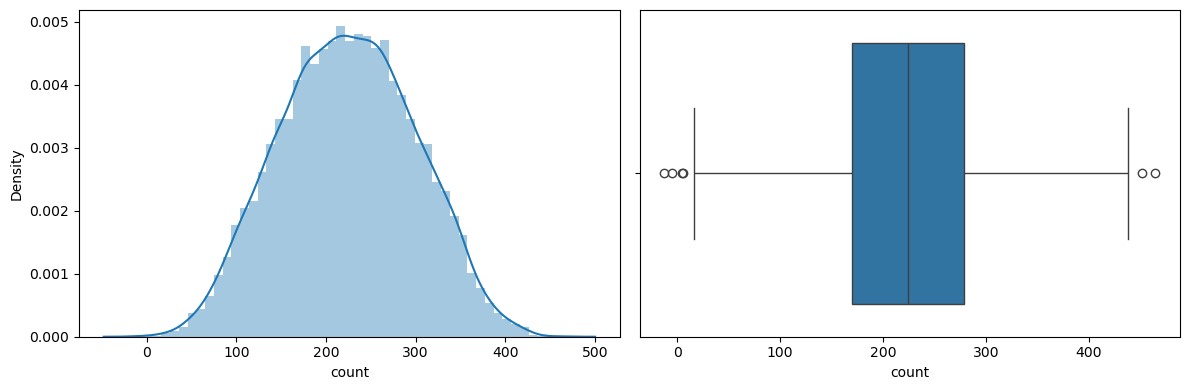

In [15]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.distplot(df['count'])
plt.subplot(1, 2, 2)
sns.boxplot(df['count'], orient='h')
plt.tight_layout()

#### Build Feature

In [70]:
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['weekday'] = df['datetime'].map(lambda x: 0 if x.weekday() > 4 else 1)
df['am_or_pm'] = df['hour'].map(lambda x: 1 if x > 11 else 0)
df['holidays'] = df['date'].map(lambda x: 1 if holidays.country_holidays('IN').get(x) else 0)

#### Time Distribution

In [84]:
time_cols = ['day', 'hour', 'month']

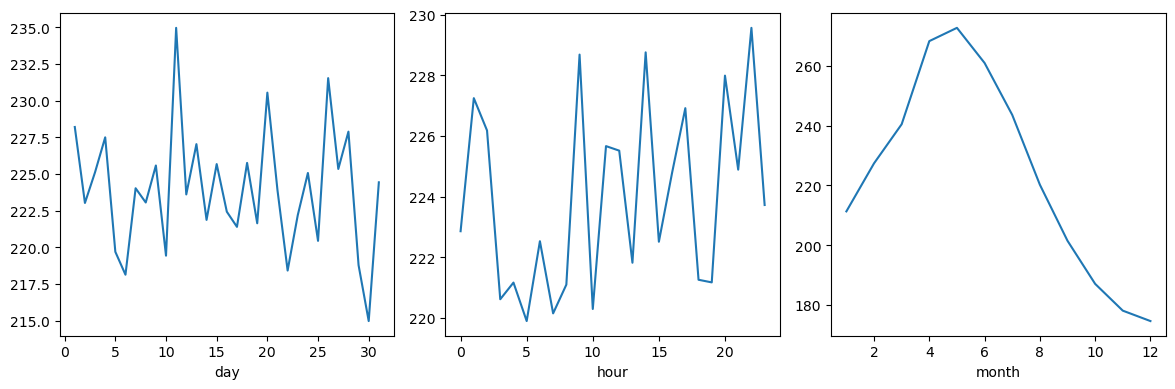

In [85]:
plt.figure(figsize=(12, 4))
for i, col in enumerate(time_cols):
    plt.subplot(1, 3, i+1)
    df.groupby(col)['count'].mean().plot()
plt.tight_layout()

#### Discrete Distribution

In [86]:
discrete_cols = ['season', 'weather', 'holidays', 'am_or_pm', 'year', 'weekday']

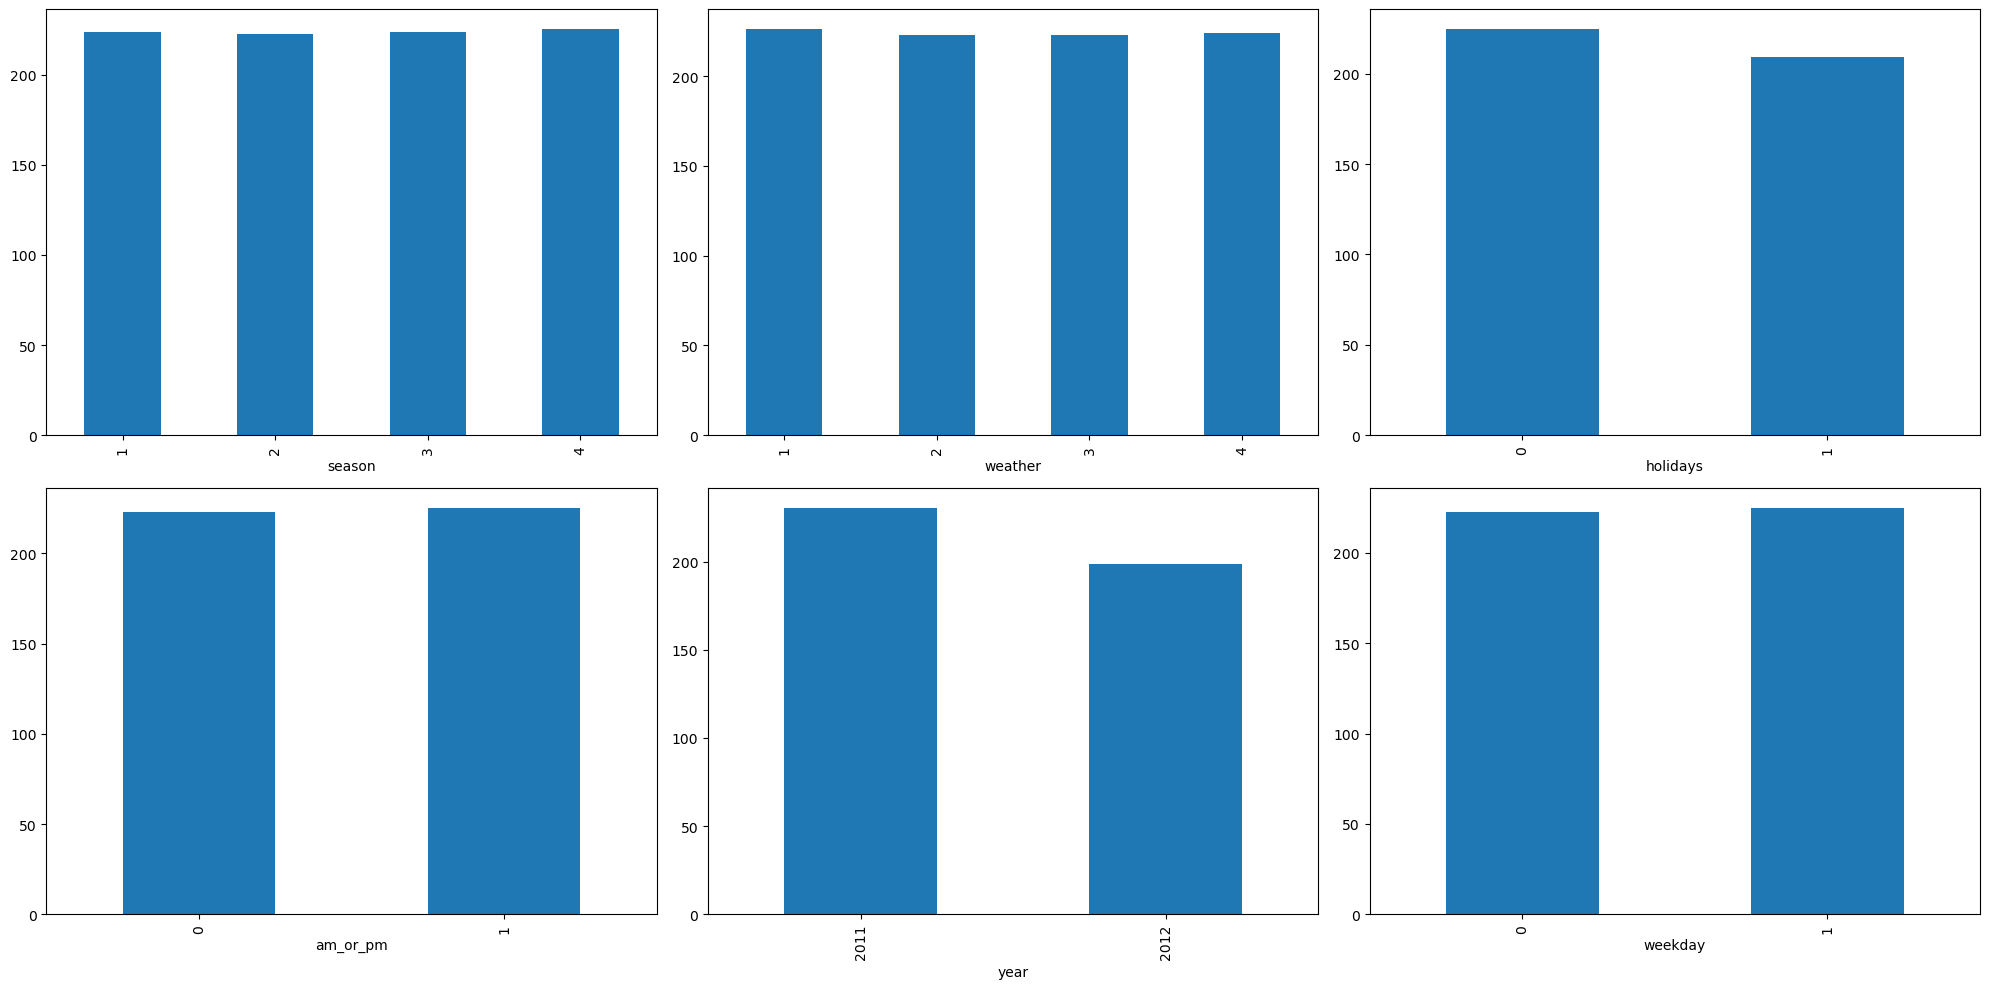

In [87]:
plt.figure(figsize=(20, 10))
for i, col in enumerate(discrete_cols):
    plt.subplot(2, 3, i+1)
    df.groupby(col)['count'].mean().plot.bar()
plt.tight_layout()

#### Environment Distribution

In [88]:
envi_cols = ['temp', 'windspeed']

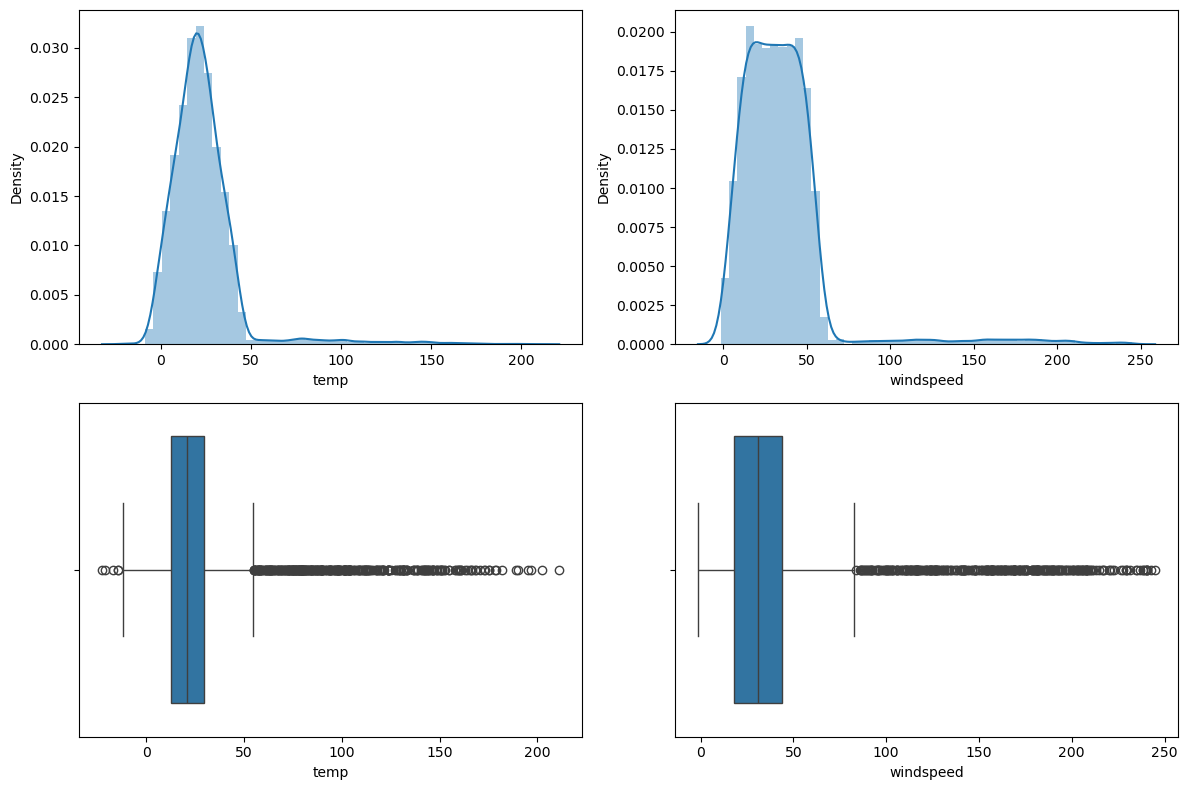

In [92]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(envi_cols):
    plt.subplot(2, 2, i+1)
    sns.distplot(df[col])
    plt.subplot(2, 2, i+3)
    sns.boxplot(df[col], orient='h')
plt.tight_layout()

#### Other Distribution

In [93]:
other_cols = ['humidity', 'casual', 'registered']

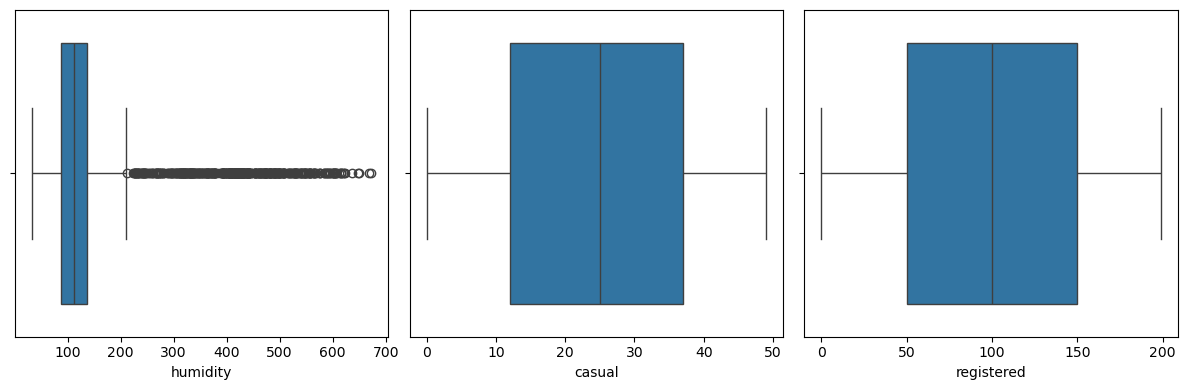

In [95]:
plt.figure(figsize=(12, 4))
for i, col in enumerate(other_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(df[col], orient='h')
plt.tight_layout()

### Step 4: Feature Engineering

#### Handling Missing Value

In [16]:
df.dropna(inplace=True, ignore_index=True)

#### Heat Map

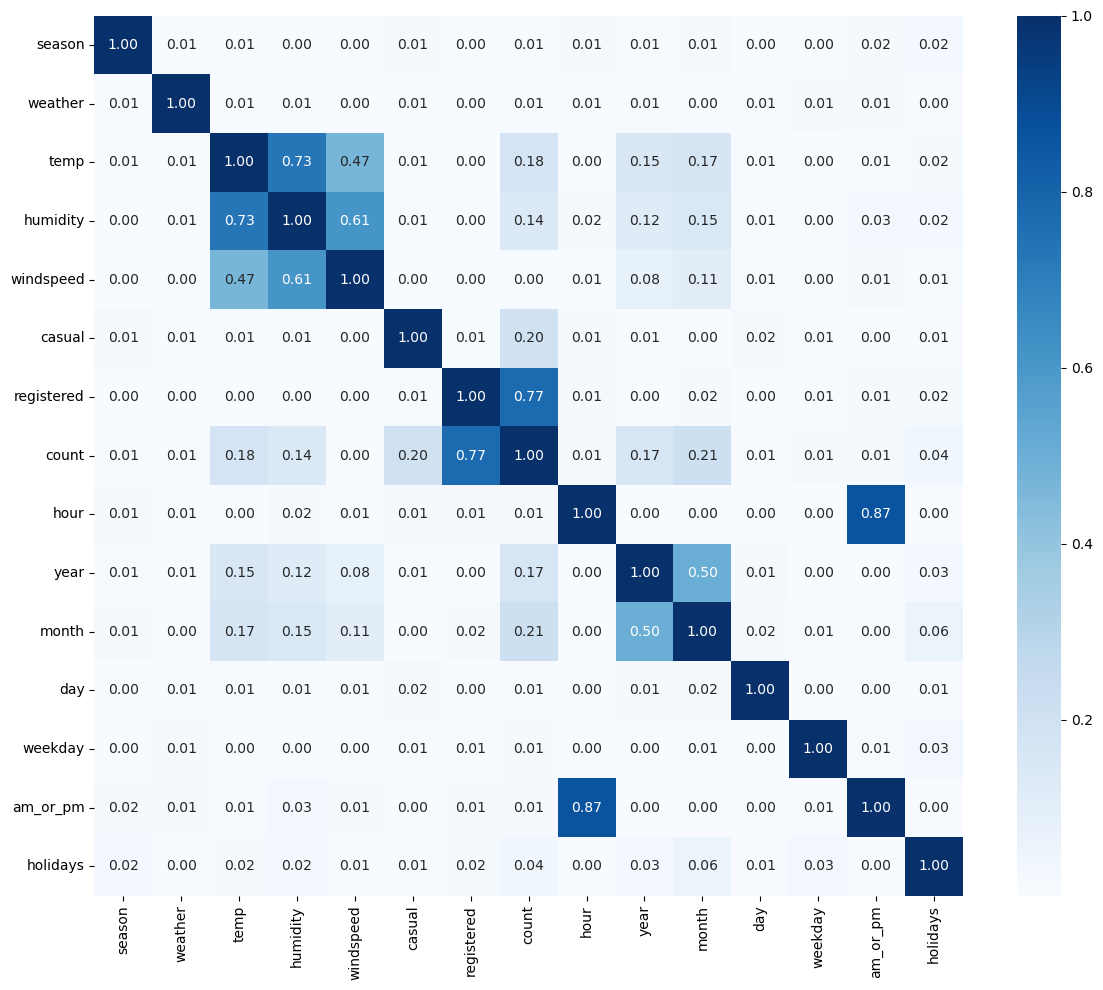

In [97]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df.select_dtypes(np.number).corr().abs(),
    fmt='.2f',
    annot=True,
    cmap=plt.cm.Blues
)
plt.tight_layout()

### Step 5: Preparing Data

#### Select Features

In [108]:
features = df.drop(['datetime', 'date', 'count'], axis=1)
target = df['count']

In [109]:
raw_features = features.columns.to_list()

In [110]:
selector = SmartCorrelatedSelection(threshold=0.8, selection_method='corr_with_target')

In [111]:
features = selector.fit_transform(features, target)

In [112]:
deal_features = features.columns.to_list()

In [113]:
print('row features:', raw_features)
print('deal features:', deal_features)
print('delete featuers:', set(raw_features)-set(deal_features))

row features: ['season', 'weather', 'temp', 'humidity', 'windspeed', 'casual', 'registered', 'hour', 'year', 'month', 'day', 'weekday', 'am_or_pm', 'holidays']
deal features: ['season', 'weather', 'temp', 'humidity', 'windspeed', 'casual', 'registered', 'year', 'month', 'day', 'weekday', 'am_or_pm', 'holidays']
delete featuers: {'hour'}


#### Split Data

In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

#### Normalization

In [119]:
scaler = StandardScaler()

In [120]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Step 6: Model Development

#### Building Model

In [122]:
models = [
    LinearRegression(),
    Lasso(),
    RandomForestRegressor(),
    Ridge()
]

#### Evaluate Model

In [123]:
for model in models:
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        error_score='raise'
    )
    print(f'model name: {model.__class__.__name__}')
    print(f'training accuracy scores: {[round(x, 2) for x in scores]}')
    print(f'training accuracy score: {round(scores.mean(), 2)}')

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f'testing Error: {metrics.mean_absolute_error(y_test, y_pred)}')
    print('-' * 20)

model name: LinearRegression
training accuracy scores: [0.76, 0.8, 0.78, 0.77, 0.77]
training accuracy score: 0.77
testing Error: 28.545457156082918
--------------------
model name: Lasso
training accuracy scores: [0.76, 0.79, 0.77, 0.77, 0.76]
training accuracy score: 0.77
testing Error: 28.665842134928074
--------------------
model name: RandomForestRegressor
training accuracy scores: [0.81, 0.83, 0.82, 0.81, 0.81]
training accuracy score: 0.81
testing Error: 25.599645951417546
--------------------
model name: Ridge
training accuracy scores: [0.76, 0.8, 0.78, 0.77, 0.77]
training accuracy score: 0.77
testing Error: 28.54562909238717
--------------------
